# Regime-aware SHAP on market volatility

`regime-shap` asks a simple question about any tree model: when the world changes
regime, do the features the model relies on stay the same, or does the model
quietly start leaning on different drivers? A model can score well overall while
resting on unstable foundations, and that is a risk you want to see before you
trust it.

This notebook works that question end to end on a genuine, public dataset. We
build an XGBoost model that predicts the next-day change in the VIX (the equity
"fear gauge") from a handful of market and rates features, let the package find
market regimes from the data, and then measure how stable the model's feature
importances are across those regimes.

**What you will learn**

1. How to shape any dataset into the `(model, X, regimes)` inputs the package expects.
2. How to let `regime_shap.breaks.detect_breaks` find regimes from a series instead of hand-labelling them.
3. How to read the stability matrix and the Akoglu (2018) bands, and what an unstable pair actually means.

This is one of the package's non-GDP examples. It is deliberately a different
domain (finance) on different public data, to show the method is domain-agnostic.

## The data

Four daily series from FRED (the Federal Reserve Bank of St. Louis), all public
and free to redistribute, none needing an API key:

| Column | FRED series | Meaning |
| --- | --- | --- |
| `vix` | `VIXCLS` | CBOE Volatility Index, expected 30-day equity volatility |
| `dgs10` | `DGS10` | 10-year Treasury yield |
| `term_spread` | `T10Y2Y` | 10-year minus 2-year Treasury yield, the curve slope |
| `oil` | `DCOILWTICO` | WTI crude oil spot price |

A static snapshot (1990 to mid-2026, aligned on common trading days) is bundled
under `data/market_regimes.csv`, so the notebook runs offline and reproduces the
same numbers for everyone. For transparency, this is exactly how the snapshot was
built, using only the public CSV endpoint:

```python
import io, urllib.request
import pandas as pd

SERIES = {"VIXCLS": "vix", "DGS10": "dgs10", "T10Y2Y": "term_spread", "DCOILWTICO": "oil"}

def fetch(series_id):
    url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}&cosd=1990-01-01"
    raw = urllib.request.urlopen(url, timeout=30).read().decode()
    df = pd.read_csv(io.StringIO(raw))
    s = pd.to_numeric(df[series_id], errors="coerce")  # FRED marks gaps with "."
    s.index = pd.to_datetime(df["observation_date"])
    return s.rename(SERIES[series_id])

data = pd.concat([fetch(s) for s in SERIES], axis=1).dropna().loc["1990-01-01":]
```

In [1]:
import numpy as np
import pandas as pd
from xgboost import XGBRegressor

from regime_shap import RegimeSHAPAnalyzer
from regime_shap.breaks import detect_breaks

%matplotlib inline

In [2]:
raw = pd.read_csv("data/market_regimes.csv", parse_dates=["date"]).set_index("date")
print(f"{len(raw):,} trading days, {raw.index.min().date()} to {raw.index.max().date()}")
raw.head()

9,085 trading days, 1990-01-02 to 2026-07-06


,vix,dgs10,term_spread,oil
date,,,,
1990-01-02,17.24,7.94,0.07,22.88
1990-01-03,18.19,7.99,0.05,23.81
1990-01-04,19.22,7.98,0.06,23.41
1990-01-05,20.11,7.99,0.09,23.07
1990-01-08,20.26,8.02,0.12,21.64


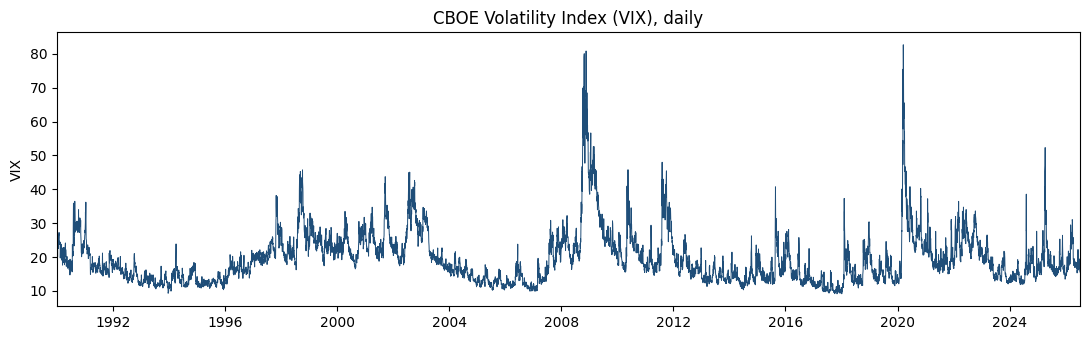

In [3]:
# A quick look at the VIX itself, the series whose regimes we will study. The
# tall spikes are the market events everyone remembers: 1998, 2008, 2020.
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(raw.index, raw["vix"], linewidth=0.7, color="#1f4e79")
ax.set_title("CBOE Volatility Index (VIX), daily")
ax.set_ylabel("VIX")
ax.margins(x=0)
fig.tight_layout();

## Features and target

The package does not care where the features come from, only that you hand it a
fitted model and the matrix `X` it was trained on. We predict the **next-day
change in the VIX** rather than its level: the level is so persistent that a model
can predict it from today's level alone, which would hide any interesting
structure. Predicting the change is a harder, more honest task that forces the
model to use every feature.

The features are all known at day `t` and are used to predict the VIX move into
day `t + 1`: the current VIX and its 5- and 20-day averages and 5-day momentum,
the rates level and curve slope, and two oil features. We use absolute dollar
changes for oil because WTI printed negative in April 2020, which would make a
percentage change meaningless across the sign flip.

In [4]:
df = pd.DataFrame(index=raw.index)
df["vix"] = raw["vix"]
df["vix_ma5"] = raw["vix"].rolling(5).mean()
df["vix_ma20"] = raw["vix"].rolling(20).mean()
df["vix_mom5"] = raw["vix"] - raw["vix"].shift(5)      # 5-day momentum
df["term_spread"] = raw["term_spread"]
df["dgs10"] = raw["dgs10"]
df["oil_chg5"] = raw["oil"].diff(5)                    # 5-day change in WTI, dollars
df["oil_vol20"] = raw["oil"].diff().rolling(20).std()  # 20-day WTI dollar volatility

target = (raw["vix"].shift(-1) - raw["vix"]).rename("vix_chg")  # next-day VIX change

model_data = df.join(target).dropna()  # rolling windows and the shift leave NaNs at the edges
X = model_data.drop(columns="vix_chg")
y = model_data["vix_chg"]
print("design matrix:", X.shape)
X.head()

design matrix: (9064, 8)


,vix,vix_ma5,vix_ma20,vix_mom5,term_spread,dgs10,oil_chg5,oil_vol20
date,,,,,,,,
1990-01-31,25.36,26.192,23.5030,-0.03,0.15,8.43,-0.74,0.848208
1990-02-01,24.87,26.040,23.8370,-0.76,0.14,8.42,-1.77,0.819066
1990-02-02,24.32,25.648,24.0920,-1.96,0.13,8.50,0.48,0.819148
1990-02-05,24.54,25.268,24.3135,-1.90,0.16,8.53,-0.35,0.826548
1990-02-06,24.69,24.756,24.5350,-2.56,0.15,8.57,0.07,0.758665


## Let the data pick the regimes

Rather than hand-label eras, we let `detect_breaks` find them. It runs change-point
detection (via `ruptures`) on the VIX level and returns the row indices where the
series shifts to a new mean. We ask for three break points, which splits the
history into four contiguous regimes, and label each by the years it spans.

This is the package's own regime-finding path. You could equally pass your own
labels (a list, or date ranges) if you already know your regimes.

In [5]:
breaks = detect_breaks(raw.loc[X.index, "vix"], n_breaks=3, model="l2")
idx = X.index
bounds = [0] + [b for b in breaks if 0 < b < len(idx)] + [len(idx)]

labels = pd.Series(index=idx, dtype=object)
for lo, hi in zip(bounds[:-1], bounds[1:]):
    labels.iloc[lo:hi] = f"{idx[lo].year}-{idx[hi - 1].year}"  # inclusive last row

regimes = labels.tolist()
labels.value_counts().sort_index()

1990-1996    1710
1996-2008    2925
2008-2009     150
2009-2026    4279
Name: count, dtype: int64

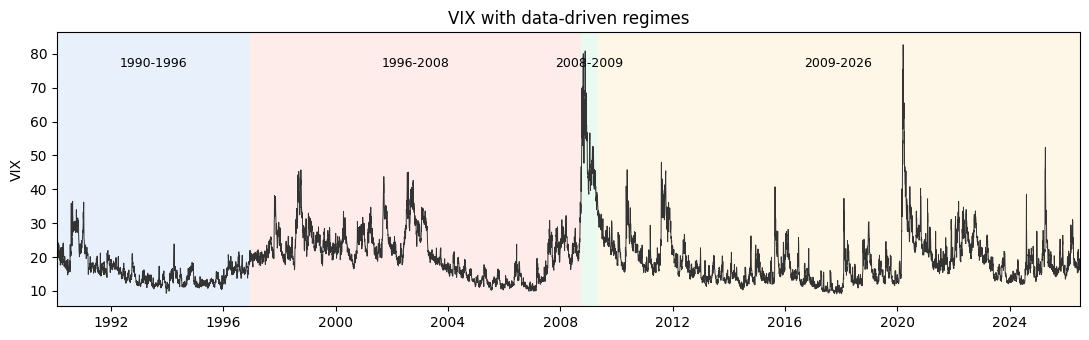

In [6]:
# The same VIX series, shaded by the regime the detector assigned. Notice it
# carves out 2008-2009, the global financial crisis, as its own short regime.
fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(idx, raw.loc[idx, "vix"], linewidth=0.7, color="#333333")
band_colors = ["#e8f0fb", "#fdecea", "#eafaf1", "#fef6e7"]
for (lo, hi), c in zip(zip(bounds[:-1], bounds[1:]), band_colors):
    ax.axvspan(idx[lo], idx[hi - 1], color=c)
    mid = idx[(lo + hi) // 2]
    ax.text(mid, raw["vix"].max() * 0.92, f"{idx[lo].year}-{idx[hi - 1].year}",
            ha="center", fontsize=9)
ax.set_title("VIX with data-driven regimes")
ax.set_ylabel("VIX")
ax.margins(x=0)
fig.tight_layout();

## Fit the model

Any model that `shap.TreeExplainer` supports will do. We use a gradient-boosted
tree. The goal here is a reasonable model to interrogate, not a production
volatility forecast, so we fit on the whole history and report the in-sample fit
only to confirm the model has learned something to explain.

In [7]:
model = XGBRegressor(
    n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.8, random_state=42
)
model.fit(X, y)
print(f"in-sample R^2: {model.score(X, y):.3f}")

in-sample R^2: 0.419


## Run the analysis

`RegimeSHAPAnalyzer` does the rest in one object: it computes SHAP values once,
then serves global and per-regime importance, the cross-regime stability matrix,
plots, and reports. Everything below is just reading views off this one call.

In [8]:
analyzer = RegimeSHAPAnalyzer(model, X, regimes)
analyzer.global_importance().round(3)

vix            0.193
vix_ma20       0.109
vix_mom5       0.088
vix_ma5        0.087
dgs10          0.078
term_spread    0.059
oil_vol20      0.052
oil_chg5       0.051
Name: mean_abs_shap, dtype: float32

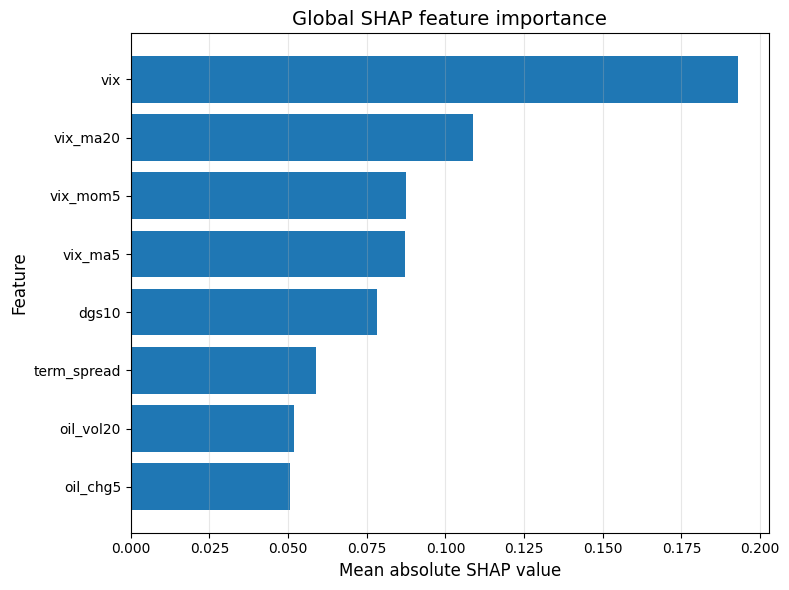

In [9]:
analyzer.plot_global();

## Where does each regime put its weight?

Global importance hides the very thing we care about. The per-regime view shows
each feature's importance rank within each regime, and this is where the regimes
start to disagree.

In [10]:
analyzer.per_regime_rankings()

,1990-1996,1996-2008,2008-2009,2009-2026
vix,1.0,1.0,1.0,1.0
vix_ma5,5.0,4.0,3.0,5.0
vix_ma20,3.0,2.0,2.0,3.0
vix_mom5,6.0,3.0,5.0,2.0
term_spread,7.0,6.0,7.0,6.0
dgs10,2.0,5.0,8.0,4.0
oil_chg5,8.0,8.0,4.0,7.0
oil_vol20,4.0,7.0,6.0,8.0


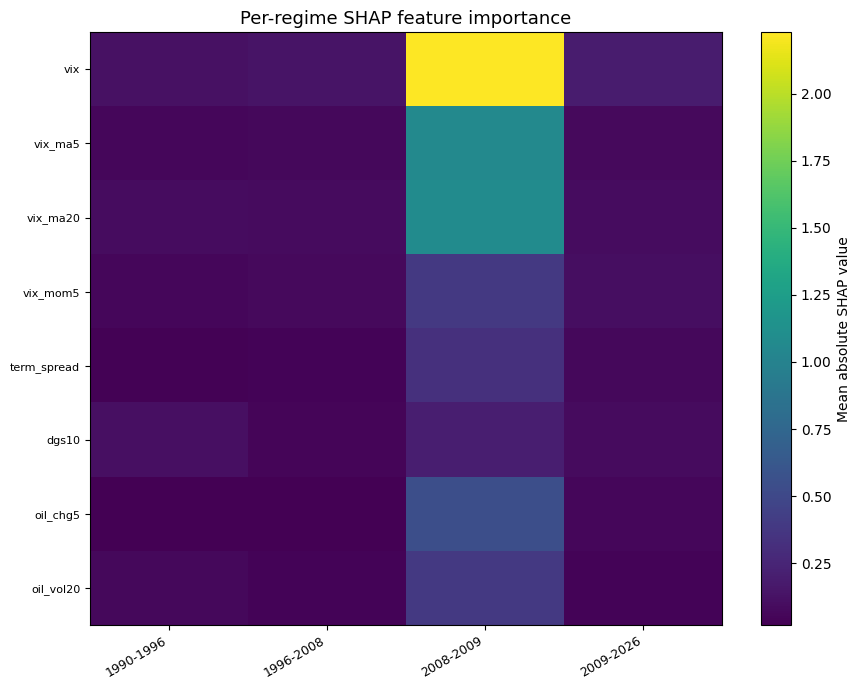

In [11]:
analyzer.plot_per_regime();

## Stability across regimes

The stability matrix is the headline. Each cell is the Spearman rank correlation
between two regimes' feature-importance rankings: 1.0 means the two regimes agree
perfectly on what matters, and low values mean the model has reshuffled its
drivers. We classify each pair with the Akoglu (2018) bands:

- **stable**: rho above 0.6, the drivers hold
- **moderately stable**: rho between 0.3 and 0.6
- **unstable**: rho at or below 0.3, the drivers have genuinely changed

In [12]:
analyzer.stability_matrix().round(3)

,1990-1996,1996-2008,2008-2009,2009-2026
1990-1996,1.000,0.643,0.262,0.548
1996-2008,0.643,1.000,0.619,0.929
2008-2009,0.262,0.619,1.000,0.476
2009-2026,0.548,0.929,0.476,1.000


In [13]:
analyzer.stability_classified()

,regime_a,regime_b,spearman_rho,band,involves_small_regime
0,1990-1996,1996-2008,0.642857,stable,False
1,1990-1996,2008-2009,0.261905,unstable,False
2,1990-1996,2009-2026,0.547619,moderately stable,False
3,1996-2008,2008-2009,0.619048,stable,False
4,1996-2008,2009-2026,0.928571,stable,False
5,2008-2009,2009-2026,0.476190,moderately stable,False


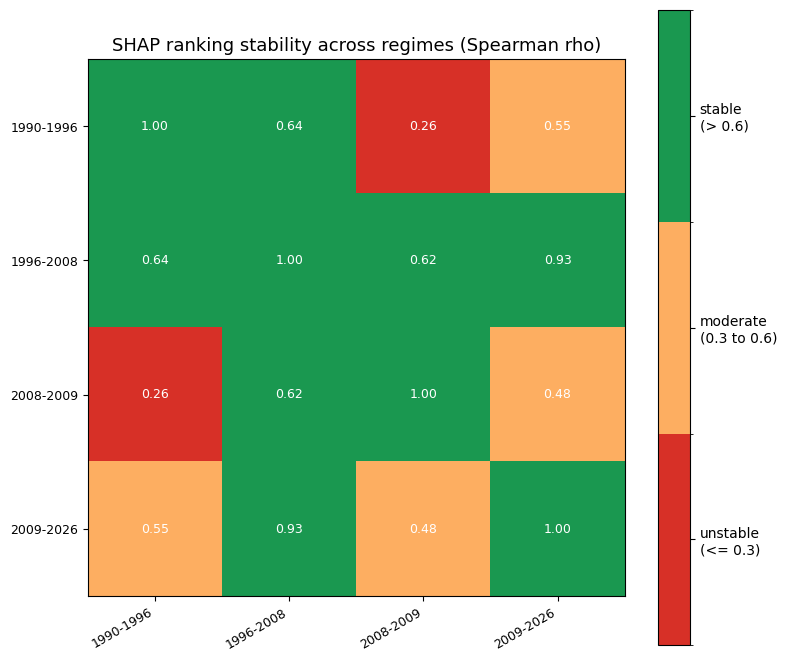

In [14]:
analyzer.plot_stability();

Read across the classified table and the heatmap and a clear pattern emerges. The
two calm, non-crisis regimes agree strongly with each other (the 1996-2008 and
2009-2026 pair sits near 0.93, comfortably stable). The instability is
concentrated on the crisis: the early-1990s regime and the 2008-2009 crisis
regime fall into the **unstable** band, and every pair that touches the crisis
regime is the least stable in its row.

That is the finding worth taking away. This model's drivers are dependable in
ordinary markets but reorganise in a crisis: the rates level (`dgs10`), which
ranks near the top in the calm early regime, drops to the bottom during
2008-2009, while the oil features climb. A single global importance chart would
have hidden that entirely.

## Small regimes

When a regime has very few observations its ranking is noisy, so the analyzer
flags small regimes and, for pairs that involve one, can attach bootstrap
confidence intervals to the correlation. Here even the short crisis regime has
150 days, above the default threshold of 10, so nothing is flagged. The check is
worth keeping in view for datasets where a regime really is tiny.

In [15]:
analyzer.sample_sizes()

,regime,n_observations,small_sample
0,1990-1996,1710,False
1,1996-2008,2925,False
2,2008-2009,150,False
3,2009-2026,4279,False


## Save the results

The analyzer exports the same tables to a self-contained HTML report or to CSVs,
so results can travel outside the notebook.

In [16]:
import tempfile
from pathlib import Path

out_dir = Path(tempfile.mkdtemp())
paths = analyzer.save_csv(out_dir)
html = analyzer.to_html(title="Market volatility: SHAP stability across regimes")
print(f"wrote {len(paths)} CSV tables and a {len(html):,}-character HTML report to {out_dir}")

wrote 6 CSV tables and a 6,505-character HTML report to /var/folders/0m/7cd4sg3s2h9_28bz90nk68wr0000gn/T/tmprslpwjzf


## Adapt this to your own data

The whole notebook is one pattern you can lift:

1. Assemble a feature matrix `X` and a target `y`.
2. Fit any `shap.TreeExplainer`-compatible model.
3. Get regime labels, either from `detect_breaks` or your own knowledge, one per row of `X`.
4. `RegimeSHAPAnalyzer(model, X, regimes)`, then read `.stability_classified()` and `.plot_stability()`.

Swap in energy demand, credit risk, or any domain with real time-based regimes and
the same three questions apply: what drives the model, does that change across
regimes, and can you trust it when the regime turns.